# TAHMO Data for Kieni Project

This notebook aims to demonstrate how to access and process weather data from the Trans-African Hydro-Meteorological Observatory (TAHMO) for the Kieni region. This data can be crucial for various applications, such as agricultural planning, climate research, and disaster preparedness.

In [ ]:
!pip install filter-stations==0.7.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.8/318.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.1 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


## TAHMO API Authentication

To access the TAHMO data, you need to authenticate using your username and password. The `RetrieveData` class from the `filter_stations` library handles this authentication.

Please replace the placeholder values for `USERNAME` and `PASSWORD` with your actual TAHMO credentials. info@tahmo.org

In [ ]:
from filter_stations import RetrieveData

# Probably should not be left here
USERNAME = 'Lacuna@DeKUT'
PASSWORD = 'icNve(t_Fb#4r'

rd = RetrieveData(USERNAME, PASSWORD)

## Get Station Metadata

After authenticating, the next step is to retrieve the metadata for all available TAHMO stations. This metadata includes important information such as station codes, geographical coordinates (latitude and longitude), elevation, installation dates, and other relevant details. This information is crucial for filtering stations, visualizing their distribution, and subsequently requesting specific data from them.

In [ ]:
# Get stations Metadata
stations_metadata = rd.get_stations_info()
stations_metadata.head()

,code,status,installationdate,elevationground,sensorinstallations,dataloggerinstallations,creatorid,created,updaterid,updated,...,location.countrycode,location.zipcode,location.latitude,location.longitude,location.elevationmsl,location.note,location.creatorid,location.created,location.updaterid,location.updated
0,TA00020,1,2015-05-28T00:00:00Z,2.0,None,None,2,2018-11-09T14:57:40.121861Z,2,2018-11-09T14:57:40.121861Z,...,KE,,-1.653356,36.862397,1643.0,{},2,2018-10-26T13:16:36.222199Z,2,2018-10-26T13:16:36.222199Z
1,TA00024,1,2015-08-04T00:00:00Z,2.0,None,None,2,2018-11-09T16:08:53.644026Z,2,2018-11-09T16:08:53.644026Z,...,KE,,-1.071731,37.045578,1524.7,{},2,2018-10-26T13:25:11.880774Z,199,2025-09-23T13:31:06.445822Z
2,TA00025,1,2015-08-17T00:00:00Z,2.0,None,None,2,2018-11-09T16:15:44.477056Z,2,2018-11-09T16:15:44.477056Z,...,KE,,-1.301839,36.760200,1801.8,{},2,2018-10-26T13:26:24.166069Z,199,2025-09-23T13:29:51.166524Z
3,TA00026,1,2015-08-28T00:00:00Z,3.0,None,None,2,2018-12-11T08:15:40.289703Z,2,2018-12-11T08:15:40.289703Z,...,KE,,-0.287122,36.169981,1939.9,{},2,2018-10-26T13:27:43.87694Z,199,2025-09-23T13:47:13.561605Z
4,TA00029,1,2015-09-02T00:00:00Z,2.0,None,None,2,2018-12-11T08:36:19.30342Z,2,2018-12-11T08:36:19.30342Z,...,KE,,-0.500776,36.587511,2545.8,{},2,2018-10-26T13:33:31.451613Z,199,2025-09-23T13:48:56.600974Z


## Visualize Station Distribution

This section visualizes the geographical distribution of TAHMO stations relative to the Kieni region. The map displays all available stations, highlights the central point of Kieni, and outlines a 100km radius around it. This visualization helps in understanding the coverage of TAHMO stations in the area of interest and in selecting relevant stations for data extraction.

In [ ]:
# @title Visualisation
from os import name
import plotly.express as px
import plotly.graph_objects as go
import math

# Kieni central point
kieni_lat = -0.833111
kieni_lon = 36.669667
RADIUS_KM = 100

# 1. Helper function to calculate a 100km polygon boundary
def generate_circle_polygon(lat, lon, radius_km, num_points=64):
    """Generates lat/lon pairs for a circle of a given radius in km."""
    points = []
    for i in range(num_points + 1):
        # Calculate angle
        angle = math.pi * 2 * i / num_points
        dx = radius_km * math.cos(angle)
        dy = radius_km * math.sin(angle)

        # Convert km offsets back to degrees (Works perfectly near the equator)
        point_lat = lat + (dy / 111.32)
        point_lon = lon + (dx / (111.32 * math.cos(math.radians(lat))))
        points.append((point_lon, point_lat))

    return points

# Generate the coordinates for our radius
circle_coords = generate_circle_polygon(kieni_lat, kieni_lon, RADIUS_KM)
circle_lon, circle_lat = zip(*circle_coords)

# 2. Your existing station scatter plot (Base Layer)
fig = px.scatter_mapbox(stations_metadata,
                        lat="location.latitude",
                        lon="location.longitude",
                        hover_name="code",
                        zoom=6,
                        title="TAHMO Station Distribution with 100km Radius",
                        height=600)

# 3. Overlay the 100km Radius Boundary (Red Line)
fig.add_trace(go.Scattermapbox(
    mode="lines",
    lon=circle_lon,
    lat=circle_lat,
    line=dict(width=3, color='red'),
    name="100km Radius",
    hoverinfo="skip"
))

# 4. Overlay the Kieni Central Point (Green Marker)
fig.add_trace(go.Scattermapbox(
    mode="markers",
    lon=[kieni_lon],
    lat=[kieni_lat],
    marker=dict(size=14, color='green'),
    name="Kieni Center",
    hoverinfo="text",
    text=["Kieni Forest Study Center"]
))

# 5. Apply layout settings
fig.update_layout(mapbox_style="carto-positron")
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

## Data Extraction

In this section, we will extract specific weather variables from the TAHMO API for a defined period. The data will be retrieved for all stations within a 100km radius of the Kieni central point.

We will focus on the following key meteorological parameters:

*   Daily Precipitation
*   Minimum Daily Temperature
*   Maximum Daily Temperature
*   Mean Daily Temperature
*   Mean Humidity
*   Total Daily Shortwave Radiation

In [ ]:
import pandas as pd

# Extract Data

# list of stations
stations_list = stations_metadata.code.to_list()

start_date = '2024-07-01'
end_date = '2024-12-31'

print(f"Fetching data from {start_date} to {end_date}")

Fetching data from 2024-07-01 to 2024-12-31


### Variables

This section displays all the available variables that can be queried from the TAHMO API, along with their descriptions and units. This helps in identifying the correct shortcodes for data extraction.

In [ ]:
variables = rd.get_variables()
print('Available variables in TAHMO API:')
for variable in variables:
    print('%s [%s] with shortcode "%s"' %
          (variables[variable]['description'], variables[variable]['units'], variables[variable]['shortcode']))

Available variables in TAHMO API:
Atmospheric pressure [kPa] with shortcode "ap"
Depth of water [mm] with shortcode "dw"
Electrical conductivity of precipitation [mS/cm] with shortcode "ec"
Electrical conductivity of water [mS/cm] with shortcode "ew"
Lightning distance [km] with shortcode "ld"
Lightning events [-] with shortcode "le"
Shortwave radiation [W/m2] with shortcode "ra"
Soil moisture content [m3/m3] with shortcode "sm"
Soil temperature [degrees Celsius] with shortcode "st"
Surface air temperature [degrees Celsius] with shortcode "te"
Vapor pressure [kPa] with shortcode "vp"
Wind gusts [m/s] with shortcode "wg"
Wind speed [m/s] with shortcode "ws"
Temperature of humidity sensor [degrees Celsius] with shortcode "ht"
X-axis level [degrees] with shortcode "tx"
Y-axis level [degrees] with shortcode "ty"
Logger battery percentage [-] with shortcode "lb"
Logger reference pressure [kPa] with shortcode "lp"
Logger temperature [degrees Celsius] with shortcode "lt"
Cumulative precipitat

In [ ]:
import random
import matplotlib.pyplot as plt

def random_plot(df, variable_name="Values"):
  """
  Plots the time series for a random station from the given DataFrame.

  Args:
      df (pd.DataFrame): DataFrame where columns are station codes and index is time.
      variable_name (str): The name of the variable being plotted (e.g., 'Precipitation').
  """
  if df.empty or df.shape[1] == 0:
      print("DataFrame is empty or has no stations to plot.")
      return

  # Select a random station (column)
  random_station = random.choice(df.columns.to_list())

  plt.figure(figsize=(12, 6))
  df[random_station].plot()
  plt.title(f'{variable_name} for Station: {random_station}')
  plt.xlabel('Date')
  plt.ylabel(variable_name)
  plt.grid(True)
  plt.tight_layout()
  plt.show()


### Total Precipitation

Here, we extract and aggregate the total daily precipitation (shortcode 'pr') for all selected stations. Precipitation data is crucial for understanding water availability and drought conditions.

In [ ]:
total_precipitation = rd.multiple_measurements(
    stations_list=stations_list,
    startDate=start_date,
    endDate=end_date,
    variables=['pr'],
)

# aggregate the 5 minute values daily
total_precipitation = rd.aggregate_variables(total_precipitation,
                                             method='sum',
                                             freq='1D')

Retrieving data for stations:   0%|          | 0/46 [00:00<?, ?it/s]

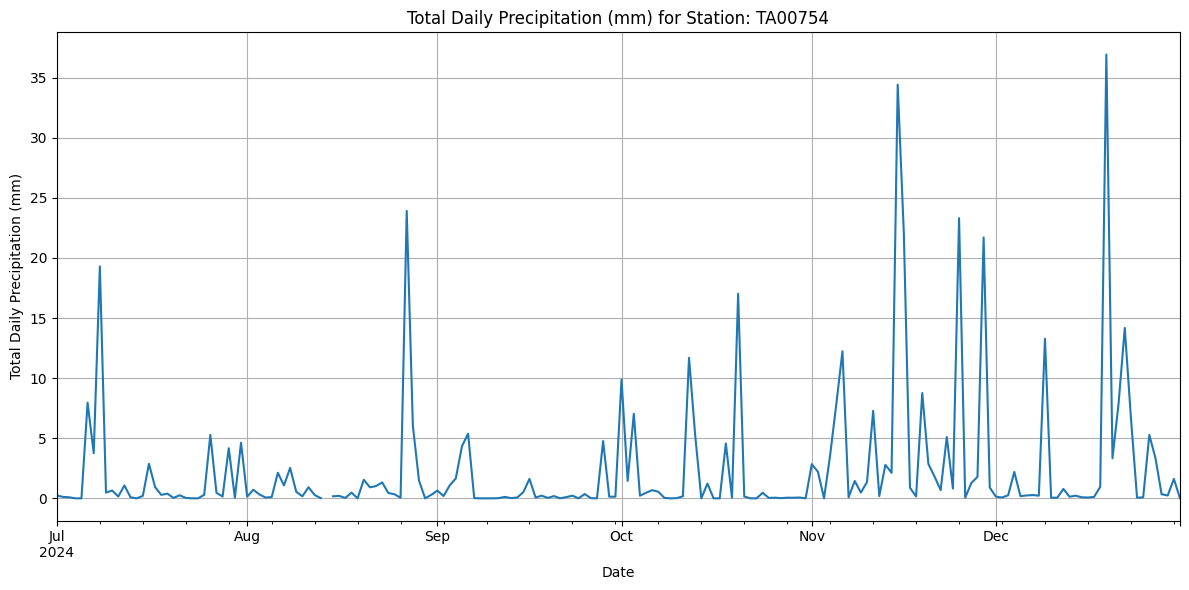

In [ ]:
# Plot a random station's total precipitation
random_plot(total_precipitation, variable_name='Total Daily Precipitation (mm)')

### Daily Minimum Temperature

This section retrieves and aggregates the daily minimum temperature (shortcode 'te') for all stations. Minimum temperatures are important for assessing frost risk and plant cold stress.

In [ ]:
min_temp = rd.multiple_measurements(
    stations_list=stations_list,
    startDate=start_date,
    endDate=end_date,
    variables=['te'],
    aggregate='5min'
)

# Aggregate daily computing the minimum values
min_temp = rd.aggregate_variables(min_temp,
                                  method='min',
                                  freq='1D')

Retrieving data for stations:   0%|          | 0/46 [00:00<?, ?it/s]

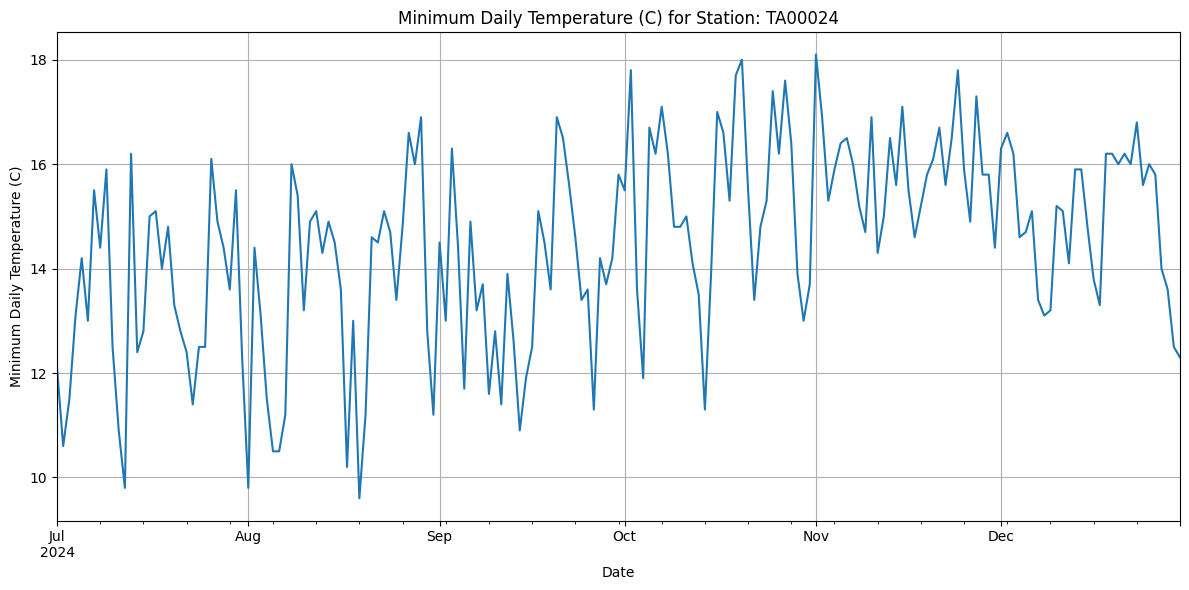

In [ ]:
# plot minimum temperature daily precipitation
random_plot(min_temp, variable_name='Minimum Daily Temperature (C)')

### Maximum Temperature

We extract and aggregate the daily maximum temperature (shortcode 'te') for all stations. Maximum temperatures are vital for evaluating heat stress on crops and livestock.

In [ ]:
max_temp = rd.multiple_measurements(
    stations_list=stations_list,
    startDate=start_date,
    endDate=end_date,
    variables=['te'],
    aggregate='5min'
)

# aggregate daily computing the maximum values
max_temp = rd.aggregate_variables(max_temp,
                                  method='max',
                                  freq='1D')

Retrieving data for stations:   0%|          | 0/46 [00:00<?, ?it/s]

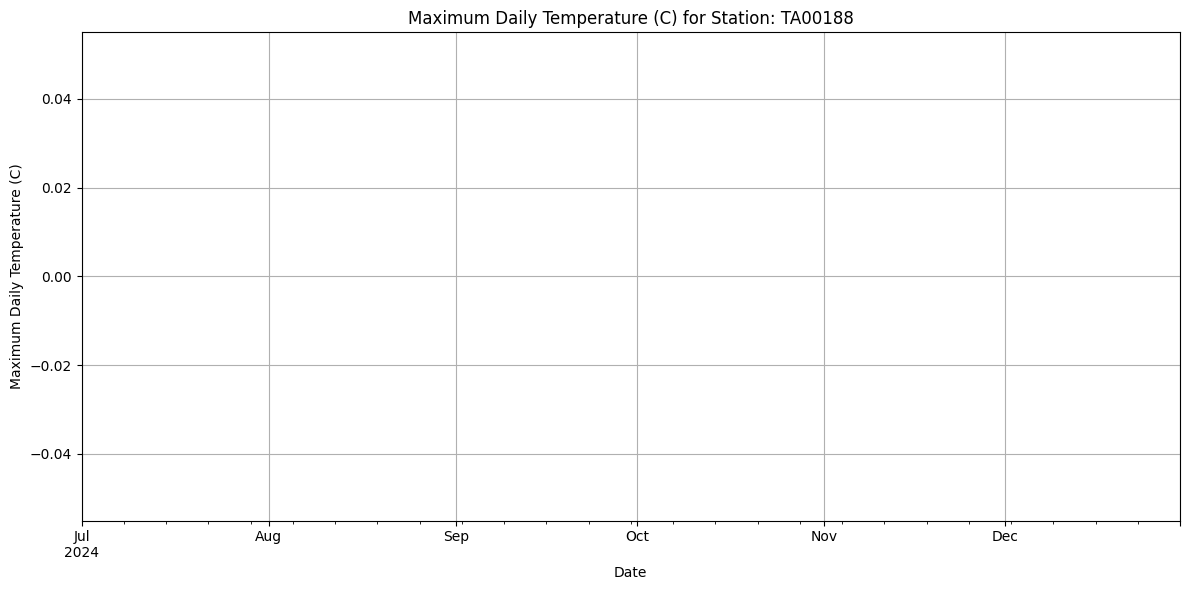

In [ ]:
# plot a random station max temp values
random_plot(max_temp, variable_name='Maximum Daily Temperature (C)')

### Mean Temperature

This part focuses on extracting and aggregating the mean daily temperature (shortcode 'te') for all stations. Mean temperatures provide a general overview of the daily thermal conditions.

In [ ]:
avg_temp = rd.multiple_measurements(
    stations_list=stations_list,
    startDate=start_date,
    endDate=end_date,
    variables=['te'],
    aggregate='5min'
)

# aggregate daily computing the average values
avg_temp = rd.aggregate_variables(avg_temp,
                                  method='mean',
                                  freq='1D')

Retrieving data for stations:   0%|          | 0/46 [00:00<?, ?it/s]

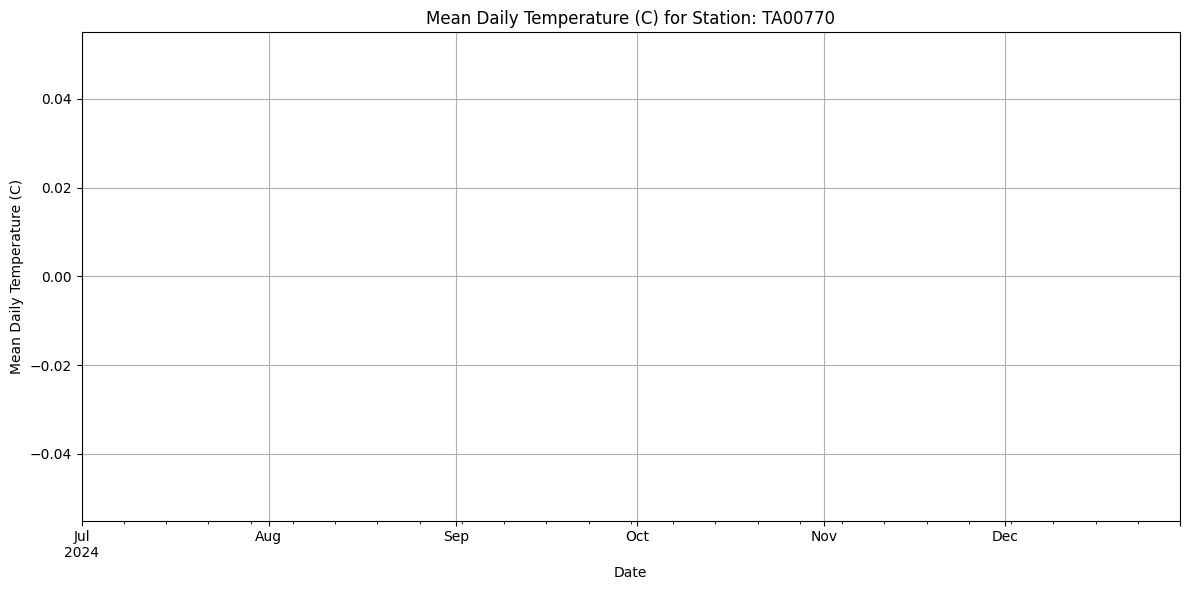

In [ ]:
# plot a random station values
random_plot(avg_temp, variable_name='Mean Daily Temperature (C)')

### Mean Humidity

Here, we retrieve and aggregate the mean daily relative humidity (shortcode 'rh') for all selected stations. Humidity levels influence evapotranspiration, plant health, and comfort levels.

In [ ]:
avg_rh = rd.multiple_measurements(
    stations_list=stations_list,
    startDate=start_date,
    endDate=end_date,
    variables=['rh'],
    aggregate='5min'
)

# aggregate the average daily relative humidity
avg_rh = rd.aggregate_variables(avg_rh,
                                method='mean',
                                freq='1D')

Retrieving data for stations:   0%|          | 0/46 [00:00<?, ?it/s]

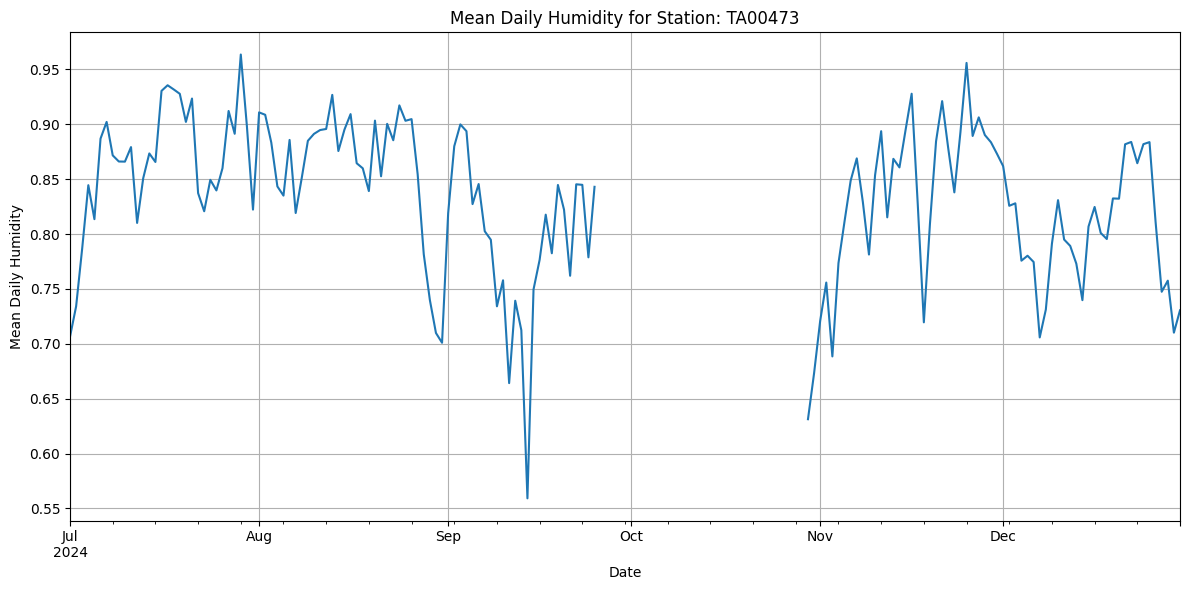

In [ ]:
# plot a random station to visualise relative humidity
random_plot(avg_rh, variable_name='Mean Daily Humidity')

### Total Shortwave Radiation

Finally, this section extracts and aggregates the total daily shortwave radiation (shortcode 'ra') for all stations. Shortwave radiation is a key driver for photosynthesis and energy balance.

In [ ]:
total_radiation = rd.multiple_measurements(
    stations_list=stations_list,
    startDate=start_date,
    endDate=end_date,
    variables=['ra'],
    aggregate='5min'
)

# aggregate the 5 minute values daily
total_radiation = rd.aggregate_variables(total_radiation,
                                          method='sum',
                                          freq='1D')

Retrieving data for stations:   0%|          | 0/46 [00:00<?, ?it/s]

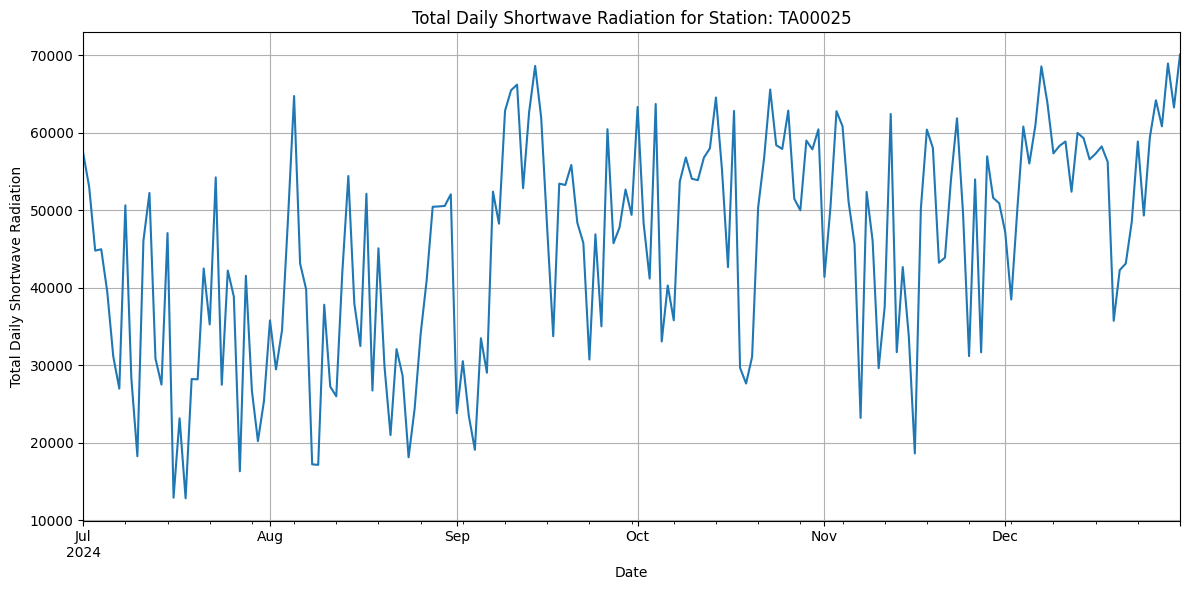

In [ ]:
# Plot random station total radiation
random_plot(total_radiation, variable_name='Total Daily Shortwave Radiation')

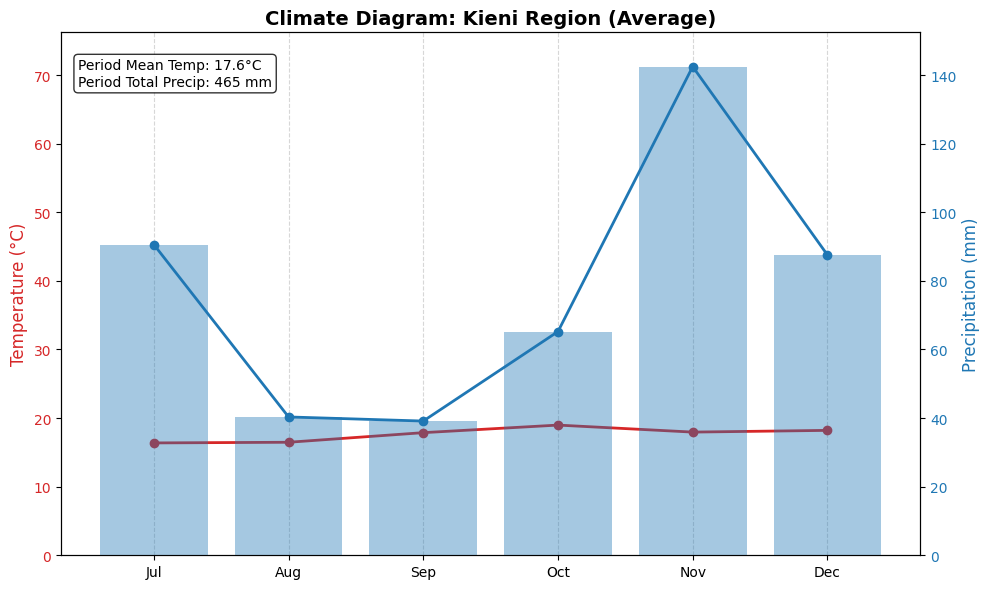

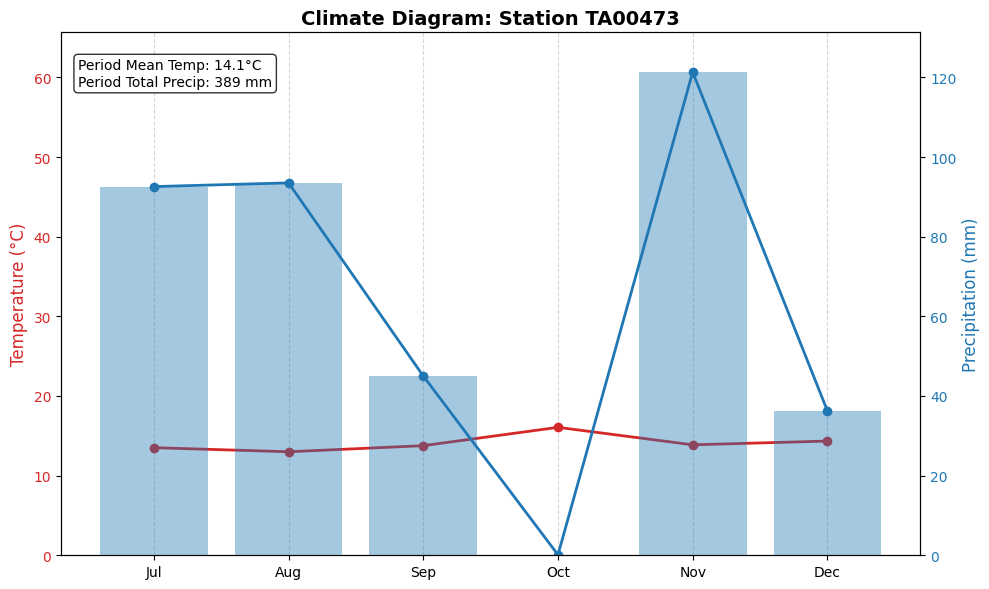

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import calendar
import pandas as pd
import random

def plot_climate_diagram(temp_df, precip_df, station_name="Region Average"):
    """
    Generates a Walter-Lieth style climate diagram.
    """
    # If a DataFrame is passed (region), calculate the spatial average first
    if isinstance(temp_df, pd.DataFrame):
        t_data = temp_df.mean(axis=1)
        p_data = precip_df.mean(axis=1)
    else:
        t_data = temp_df
        p_data = precip_df

    # 1. Calculate Monthly Climatology
    # Resample to monthly values
    monthly_temp = t_data.resample('ME').mean()
    monthly_precip = p_data.resample('ME').sum()

    # Get unique month names present in the data to avoid dimension mismatch
    month_indices = monthly_temp.index.month
    months = [calendar.month_abbr[i] for i in month_indices]

    # 2. Setup the Plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    # 3. Plot Temperature (Red Line)
    ax1.plot(months, monthly_temp.values, color='#d62728', linewidth=2, marker='o', label='Mean Temp (°C)')
    ax1.set_ylabel('Temperature (°C)', color='#d62728', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='#d62728')

    # 4. Plot Precipitation (Blue Bars/Line)
    ax2.bar(months, monthly_precip.values, color='#1f77b4', alpha=0.4, label='Precipitation (mm)')
    ax2.plot(months, monthly_precip.values, color='#1f77b4', linewidth=2, marker='o')
    ax2.set_ylabel('Precipitation (mm)', color='#1f77b4', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='#1f77b4')

    # 5. Scaling
    limit_t = max(monthly_temp.max(), monthly_precip.max() / 2) + 5
    ax1.set_ylim(0, limit_t)
    ax2.set_ylim(0, limit_t * 2)

    # 6. Formatting
    plt.title(f'Climate Diagram: {station_name}', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', linestyle='--', alpha=0.5)

    # Summary text
    annual_precip = monthly_precip.sum()
    annual_temp = monthly_temp.mean()
    summary_text = f"Period Mean Temp: {annual_temp:.1f}°C\nPeriod Total Precip: {annual_precip:.0f} mm"
    plt.text(0.02, 0.95, summary_text, transform=ax1.transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# Example 1: Entire Region Average
plot_climate_diagram(avg_temp, total_precipitation, station_name="Kieni Region (Average)")

# Example 2: Single Random Station
random_station = random.choice(stations_list)
plot_climate_diagram(avg_temp[random_station], total_precipitation[random_station], station_name=f"Station {random_station}")

In [ ]:
def get_seasonal_totals(df, season_months, season_name):
    """
    Calculates the total precipitation for specific seasons across all years.

    Args:
        df (pd.DataFrame): Daily precipitation dataframe (index must be datetime).
        season_months (list): List of month integers (e.g., [3, 4, 5] for MAM).
        season_name (str): Label for the output column.

    Returns:
        pd.DataFrame: Yearly seasonal totals for all stations.
    """
    # 1. Filter the DataFrame to only include the target months
    seasonal_data = df[df.index.month.isin(season_months)]

    # 2. Resample the filtered data by Year ('YE') and sum
    yearly_totals = seasonal_data.resample('YE').sum()

    # 3. Change the index to just show the Year (integer) for cleaner merging later
    yearly_totals.index = yearly_totals.index.year
    yearly_totals.index.name = 'Year'

    return yearly_totals



# Extract OND (October, November, December)
ond_totals = get_seasonal_totals(total_precipitation, [10, 11, 12], 'OND')

# Display the regional average for MAM rains per year
print("OND Regional Average Precipitation (mm):")
print(ond_totals.mean(axis=1))

OND Regional Average Precipitation (mm):
Year
2024    160.07013
dtype: float64
